In [1]:
import numpy as np
import pandas as pd

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [3]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [4]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [5]:
data = pd.read_csv(r"C:\Users\Tharuni\Desktop\NIT\Aug month\15th-regression practice\Dummy Data HSS.csv")

In [6]:
data

,TV,Radio,Social Media,Influencer,Sales
0,16.0,6.566231,2.907983,Mega,54.732757
1,13.0,9.237765,2.409567,Mega,46.677897
2,41.0,15.886446,2.913410,Mega,150.177829
3,83.0,30.020028,6.922304,Mega,298.246340
4,15.0,8.437408,1.405998,Micro,56.594181
...,...,...,...,...,...
4567,26.0,4.472360,0.717090,Micro,94.685866
4568,71.0,20.610685,6.545573,Nano,249.101915
4569,44.0,19.800072,5.096192,Micro,163.631457
4570,71.0,17.534640,1.940873,Macro,253.610411


In [8]:
data.head(10)

,TV,Radio,Social Media,Influencer,Sales
0,16.0,6.566231,2.907983,Mega,54.732757
1,13.0,9.237765,2.409567,Mega,46.677897
2,41.0,15.886446,2.913410,Mega,150.177829
3,83.0,30.020028,6.922304,Mega,298.246340
4,15.0,8.437408,1.405998,Micro,56.594181
5,29.0,9.614382,1.027163,Mega,105.889148
6,55.0,24.893811,4.273602,Micro,198.679825
7,31.0,17.355042,2.289855,Nano,108.733932
8,76.0,24.648898,7.130116,Macro,270.189400
9,13.0,0.431128,2.229423,Mega,48.280582


In [9]:
data.describe()

,TV,Radio,Social Media,Sales
count,4562.000000,4568.000000,4566.000000,4566.000000
mean,54.066857,18.160356,3.323956,192.466602
std,26.125054,9.676958,2.212670,93.133092
min,10.000000,0.000684,0.000031,31.199409
25%,32.000000,10.525957,1.527849,112.322882
50%,53.000000,17.859513,3.055565,189.231172
75%,77.000000,25.649730,4.807558,272.507922
max,100.000000,48.871161,13.981662,364.079751


In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social Media  4566 non-null   float64
 3   Influencer    4572 non-null   object 
 4   Sales         4566 non-null   float64
dtypes: float64(4), object(1)
memory usage: 178.7+ KB


In [12]:
data.shape

(4572, 5)

In [13]:
data.isna().sum()

TV              10
Radio            4
Social Media     6
Influencer       0
Sales            6
dtype: int64

In [14]:
data = data.dropna()

In [15]:
data.isna().sum()

TV              0
Radio           0
Social Media    0
Influencer      0
Sales           0
dtype: int64

# model building

Step 1: Pairplot to visualize relationship between pairs of variables in the data

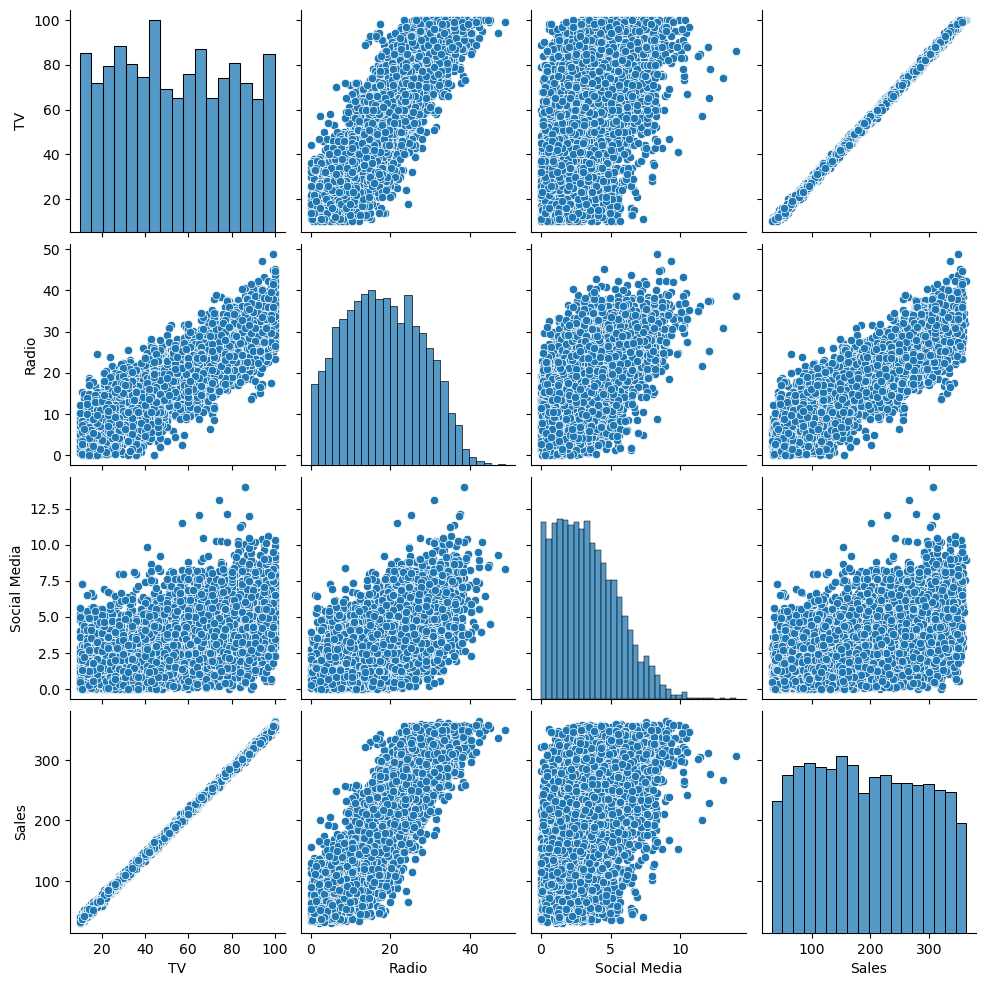

In [16]:
sns.pairplot(data)

Step 2: Build and Fit Model / Sales ~ TV

In [17]:
ols_data_TV = data[["Sales","TV"]]

In [18]:
ols_formula_TV = "Sales ~ TV" #defining ordinary least forumula

In [20]:
# Create OLS Model(ols used in regression model to find best-fitting line)

OLS_TV = ols(formula = ols_formula_TV,data = ols_data_TV)

In [21]:
# fitting the model
model_TV = OLS_TV.fit()

In [22]:
# display model result
model_TV.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Sun, 17 Aug 2025   Prob (F-statistic):               0.00
Time:                        15:47:56   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1325      0.101     -1.317      0.188      -0.330       0.065
TV             3.5615      0.002   2125.272      0.000       3.558       3.565
==============================================================================
Omnibus:                        0.052   Durbin-Watson:                   1.998
Prob(Omnibus):                  0.974   Jarque-Bera (JB):                0.031
Skew:                          -0.001   Prob(JB):                        0.985
Kurtosis:                       3.012   Cond. No.                         138.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Result Intepretation:
R-Square 0.999 --> Model explains 99.9% of the varieance, model has really high confidence
p-value > significance level of 5% --> result is statistically significant
Linear Regression Formula:
Sales (in millions) = -0.13 + 3.5 TV* (spending in millions)

Meaning 1 euros increase in TV Ad spending would increase 3.5 euros increase in Sales --> good return on investment

Step 3: Model Assumption Check
To justify using simple linear regression, check that the four linear regression assumptions are not violated. These assumptions are:

Linearity
Independent Observations
Normality
Homoscedasticity
Check Assumption: Linearity
This can be done by plotting scatterplot of x,y values to confirm linearity shape

<Axes: xlabel='TV', ylabel='Sales'>

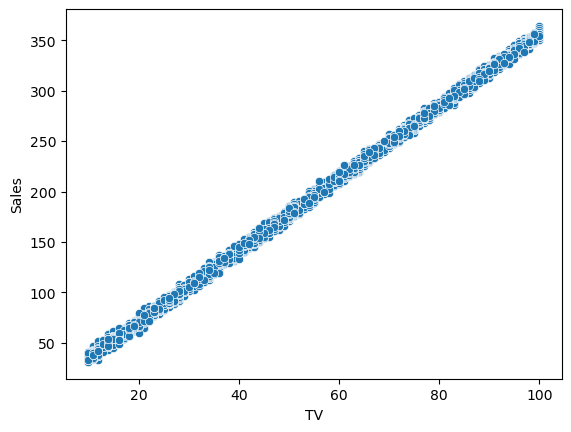

In [23]:
# create scatterplot

sns.scatterplot (x = ols_data_TV['TV'], y = ols_data_TV['Sales'])

Intepretation: datapoints follow a straight line, suggest linearity (this was also observed in pairplot)

Check Assumption: Independent Observation
Checked. Each row is independent marketing campaign.

Check Assumption: Normality
To do this, we check if the residual values (model errors) follow a normal distribution.

This can be confirmed via:

Histogram of residual values
QQPlot

In [24]:
# Calculate residuals

residuals = model_TV.resid

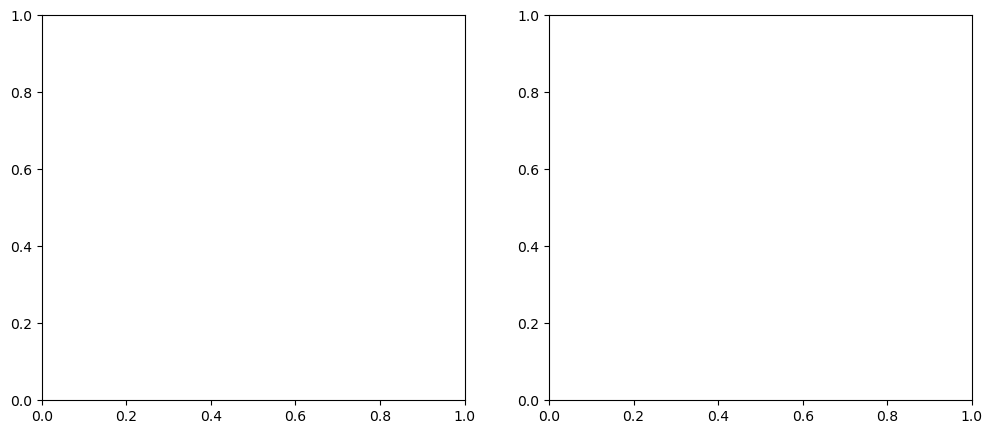

In [25]:
# Create Plot

fig, axes = plt.subplots(1,2,figsize=(12,5))

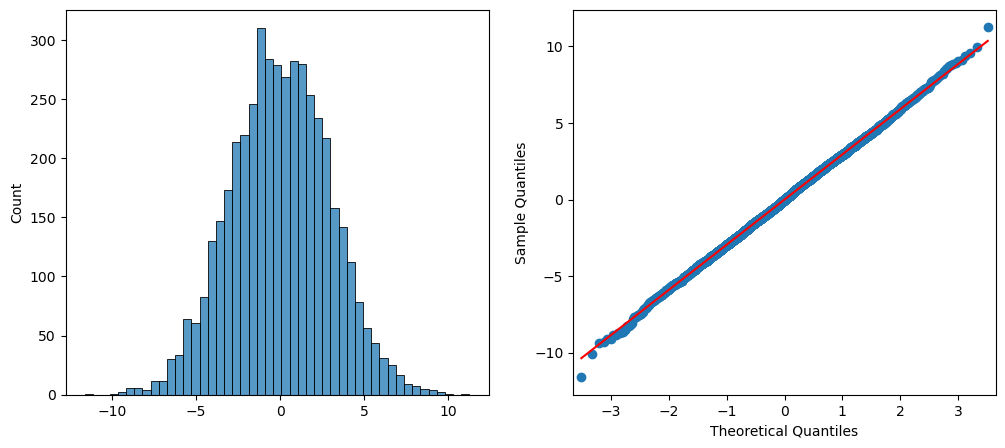

In [29]:
residuals = model_TV.resid
fig, axes = plt.subplots(1,2,figsize=(12,5))
# Put histogram in first plot
ax1 = sns.histplot(residuals,ax = axes[0])
# Place qqplot in 2nd plot
ax2 = sm.qqplot(residuals,line ="s", ax = axes[1])

Check Assumption: Homoscedasticity¶
This assumption we check if the residual values are distributed evenly for all values of independent variable (X)

To do it, we plot a scatterplot of all residual values Y for all avaible predicted value based on X

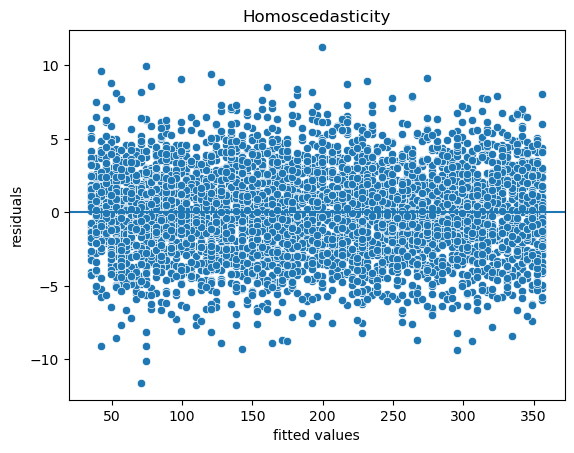

In [30]:
# Create Fitted Value (predicted value)

fitted_values = model_TV.predict(ols_data_TV["TV"])

# Create Scatter Plot

fig = sns.scatterplot (x= fitted_values, y = residuals)

fig.set_xlabel('fitted values')
fig.set_ylabel('residuals')
fig.set_title('Homoscedasticity')

# Add line 0 
fig.axhline(0)